# Step 4 — Training the Morphology CNN

**Checkpointing:** saved every 2 epochs to `checkpoints/epoch_XX.pt` + `checkpoints/best.pt`  
**Auto-resume:** if any checkpoint exists, training picks up from the latest one automatically  
**Device:** Apple MPS if available, otherwise CPU

## 4.1 Imports & Config

In [5]:
import os, sys, json, time, glob
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("step4_train.ipynb"))
sys.path.insert(0, HERE)
from model import MorphCNN

DATA_DIR = "/Users/wen/Desktop/project/archive"
HDF5_FILES = {
    "train": os.path.join(DATA_DIR, "5x64x64_training_with_morphology.hdf5"),
    "val"  : os.path.join(DATA_DIR, "5x64x64_validation_with_morphology.hdf5"),
}
CKPT_DIR = os.path.join(HERE, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

TARGET_COLS  = ["g_ellipticity", "g_major_axis", "g_sersic_index", "g_isophotal_area"]  # g band value from catelogue
EPOCHS       = 40        # increased from 20 — model hadn't converged
BATCH_SIZE   = 128
LR           = 3e-4
NUM_WORKERS  = 0
CKPT_EVERY   = 2
DEVICE       = "mps" if torch.backends.mps.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"Checkpoint dir: {CKPT_DIR}")
print(f"Epochs: {EPOCHS}")

Device: cpu
Checkpoint dir: /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/checkpoints
Epochs: 40


## 4.2 Normaliser & In-Memory Dataset

**Key change:** instead of reading one sample at a time from HDF5 (slow random I/O),  
we load all selected indices in a single sequential pass into RAM at startup (~30–60 s, one-time cost).  
After that each epoch runs entirely in memory — **~10–30× faster per epoch**.

In [6]:
with open(os.path.join(HERE, "normaliser.json")) as fp:
    NORM = json.load(fp)

def normalise_labels(vals):
    """(N, 4) raw float array -> (N, 4) normalised float32."""
    out = []
    for i, col in enumerate(TARGET_COLS):
        v = vals[:, i].astype(np.float32)
        t = NORM[col]["transform"]
        if t == "log1p": v = np.log1p(v)
        elif t == "log":  v = np.log(v)
        v = (v - NORM[col]["mean"]) / NORM[col]["std"]
        out.append(v)
    return np.stack(out, axis=1)

def denormalise(tensor):
    """(N, 4) normalised tensor -> (N, 4) original-scale numpy."""
    arr = tensor.cpu().numpy().astype(np.float64)
    out = []
    for i, col in enumerate(TARGET_COLS):
        v = arr[:, i] * NORM[col]["std"] + NORM[col]["mean"]
        t = NORM[col]["transform"]
        if t == "log1p": v = np.expm1(v)
        elif t == "log":  v = np.exp(v)
        out.append(v)
    return np.stack(out, axis=1)


# ── image stats ────────────────────────────────────────────────────────────
STATS_FILE = os.path.join(HERE, "image_stats.json")

def compute_image_stats(images_np):
    """images_np: (N,5,64,64) after arcsinh."""
    stats = {"mean": images_np.mean(axis=(0,2,3)).tolist(),
             "std" : images_np.std(axis=(0,2,3)).tolist()}
    with open(STATS_FILE, "w") as fp:
        json.dump(stats, fp, indent=2)
    return stats


# ── bulk HDF5 loader ───────────────────────────────────────────────────────
def load_split(hdf5_path, indices, desc=""):
    """Read all samples at once in sorted index order — much faster than random seeks."""
    n = len(indices)
    imgs   = np.empty((n, 5, 64, 64), dtype=np.float32)
    labels = np.empty((n, 4),          dtype=np.float32)
    print(f"Loading {desc} ({n:,} samples) ...", end="", flush=True)
    t0 = time.time()
    with h5py.File(hdf5_path, "r") as f:
        img_ds = f["image"]
        # read in chunks of 1000 to avoid huge single reads
        for start in range(0, n, 1000):
            sl = slice(start, min(start + 1000, n))
            chunk_idx = indices[sl]
            imgs[sl] = img_ds[chunk_idx]
            for j, col in enumerate(TARGET_COLS):
                labels[sl, j] = f[col][chunk_idx]
    print(f" done in {time.time()-t0:.0f}s  "
          f"(images: {imgs.nbytes/1e9:.2f} GB + labels: {labels.nbytes/1e6:.1f} MB)")
    return imgs, labels


# ── load data ──────────────────────────────────────────────────────────────
train_idx = np.load(os.path.join(HERE, "indices_train.npy"))
val_idx   = np.load(os.path.join(HERE, "indices_val.npy"))

train_imgs, train_lbls = load_split(HDF5_FILES["train"], train_idx, "train")
val_imgs,   val_lbls   = load_split(HDF5_FILES["val"],   val_idx,   "val")

# asinh stretch
train_imgs = np.arcsinh(train_imgs)
val_imgs   = np.arcsinh(val_imgs)

# compute or load image stats
if os.path.exists(STATS_FILE):
    with open(STATS_FILE) as fp:
        img_stats = json.load(fp)
    print("Loaded image_stats.json")
else:
    print("Computing image stats...")
    img_stats = compute_image_stats(train_imgs)

IMG_MEAN = np.array(img_stats["mean"], dtype=np.float32).reshape(1, 5, 1, 1)
IMG_STD  = np.array(img_stats["std"],  dtype=np.float32).reshape(1, 5, 1, 1)

# per-channel standardise
train_imgs = (train_imgs - IMG_MEAN) / IMG_STD
val_imgs   = (val_imgs   - IMG_MEAN) / IMG_STD

# normalise labels
train_lbls = normalise_labels(train_lbls)
val_lbls   = normalise_labels(val_lbls)

# convert to tensors
X_train = torch.from_numpy(train_imgs)
Y_train = torch.from_numpy(train_lbls)
X_val   = torch.from_numpy(val_imgs)
Y_val   = torch.from_numpy(val_lbls)

print(f"\nTrain tensors: X={tuple(X_train.shape)}  Y={tuple(Y_train.shape)}")
print(f"Val   tensors: X={tuple(X_val.shape)}  Y={tuple(Y_val.shape)}")


# ── In-memory Dataset ──────────────────────────────────────────────────────
from torch.utils.data import TensorDataset

train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val,   Y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE == "mps"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE == "mps"))

print(f"\nTrain: {len(train_ds):,} samples  ({len(train_loader)} batches/epoch)")
print(f"Val:   {len(val_ds):,} samples  ({len(val_loader)} batches/epoch)")

Loading train (50,000 samples) ... done in 11s  (images: 4.10 GB + labels: 0.8 MB)
Loading val (40,890 samples) ... done in 3s  (images: 3.35 GB + labels: 0.7 MB)
Loaded image_stats.json

Train tensors: X=(50000, 5, 64, 64)  Y=(50000, 4)
Val   tensors: X=(40890, 5, 64, 64)  Y=(40890, 4)

Train: 50,000 samples  (391 batches/epoch)
Val:   40,890 samples  (320 batches/epoch)


## 4.3 Model — Auto-resume from Latest Checkpoint

If `checkpoints/` already has epoch files, we load the most recent one and continue from there.

In [7]:
model     = MorphCNN(n_outputs=4).to(DEVICE)
criterion = nn.HuberLoss(delta=1.0)
optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)

# ── auto-resume ────────────────────────────────────────────────────────────
existing = sorted(glob.glob(os.path.join(CKPT_DIR, "epoch_*.pt")))
train_losses, val_losses = [], []
start_epoch = 1

if existing:
    latest = existing[-1]
    ckpt   = torch.load(latest, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt["model"])
    optimiser.load_state_dict(ckpt["optimiser"])
    scheduler.load_state_dict(ckpt["scheduler"])
    train_losses = ckpt.get("train_losses", [])
    val_losses   = ckpt.get("val_losses",   [])
    start_epoch  = ckpt["epoch"] + 1
    print(f"Resumed from {latest}  (epoch {ckpt['epoch']}, best val so far: {min(val_losses):.5f})")
else:
    print("No checkpoint found — starting from scratch")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

Resumed from /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/checkpoints/epoch_02.pt  (epoch 2, best val so far: 0.05889)
Model parameters: 3,762,532


## 4.4 Training Loop

Each epoch prints `train loss` and `val loss` as it finishes.  
Checkpoints (including optimiser + scheduler state) are saved every **2 epochs** so training can be interrupted and resumed safely.

In [8]:
def run_epoch(model, loader, criterion, optimiser, train):
    model.train(train)
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            pred = model(imgs)
            loss = criterion(pred, labels)
            if train:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            total += loss.item() * imgs.size(0)
            n     += imgs.size(0)
    return total / n


best_val = min(val_losses) if val_losses else float("inf")

for epoch in range(start_epoch, EPOCHS + 1):
    t0      = time.time()
    tr_loss = run_epoch(model, train_loader, criterion, optimiser, train=True)
    va_loss = run_epoch(model, val_loader,   criterion, optimiser, train=False)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    elapsed = time.time() - t0

    marker = " ★" if va_loss < best_val else ""
    print(f"Epoch {epoch:02d}/{EPOCHS}  train={tr_loss:.5f}  val={va_loss:.5f}  "
          f"({elapsed:.0f}s){marker}")

    # checkpoint every CKPT_EVERY epochs
    if epoch % CKPT_EVERY == 0:
        ckpt_path = os.path.join(CKPT_DIR, f"epoch_{epoch:02d}.pt")
        torch.save({
            "epoch"       : epoch,
            "model"       : model.state_dict(),
            "optimiser"   : optimiser.state_dict(),
            "scheduler"   : scheduler.state_dict(),
            "train_losses": train_losses,
            "val_losses"  : val_losses,
        }, ckpt_path)
        print(f"  -> saved {ckpt_path}")

    # always keep best
    if va_loss < best_val:
        best_val = va_loss
        torch.save({
            "epoch"     : epoch,
            "model"     : model.state_dict(),
            "val_loss"  : va_loss,
        }, os.path.join(CKPT_DIR, "best.pt"))

print(f"\nTraining complete. Best val loss: {best_val:.5f}")

Epoch 03/40  train=0.05992  val=0.05671  (544s) ★
Epoch 04/40  train=0.05415  val=0.04505  (540s) ★
  -> saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/checkpoints/epoch_04.pt
Epoch 05/40  train=0.04970  val=0.04602  (545s)
Epoch 06/40  train=0.04559  val=0.04530  (543s)
  -> saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/checkpoints/epoch_06.pt
Epoch 07/40  train=0.04184  val=0.04492  (10996s) ★
Epoch 08/40  train=0.03830  val=0.04068  (38320s) ★
  -> saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/checkpoints/epoch_08.pt
Epoch 09/40  train=0.03482  val=0.04043  (478s) ★
Epoch 10/40  train=0.03245  val=0.04537  (485s)
  -> saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/checkpoints/epoch_10.pt
Epoch 11/40  train=0.02995  val=0.04026  (486s) ★
Epoch 12/40  train=0.02730  val=0.03810  (517s) ★
  -> saved /Users/wen/Desktop/project/lizarraga_2024-main/ResCNN-MorphPredictor/checkp

## 4.5 Loss Curve

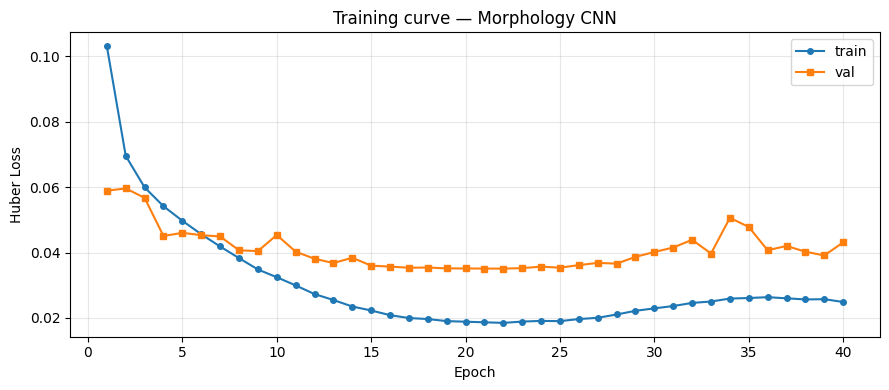

Saved loss_curve.png


In [9]:
epochs_done = list(range(1, len(train_losses) + 1))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_done, train_losses, label="train", marker="o", markersize=4)
ax.plot(epochs_done, val_losses,   label="val",   marker="s", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.set_title("Training curve — Morphology CNN")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(HERE, "figures/loss_curve.png"), dpi=110, bbox_inches="tight")
plt.show()
print("Saved loss_curve.png")